In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report)
import time
import json
import os

# Load the preprocessed data saved on Day 2
with open('../models/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
le = data['label_encoder']
scaler = data['scaler']
feature_names = data['feature_names']

print("Data loaded successfully")
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")
print(f"Features:         {X_train.shape[1]}")
print(f"Labels:           {le.classes_}")

Data loaded successfully
Training samples: 177,011
Testing samples:  44,253
Features:         77
Labels:           ['Benign' 'DDoS']


In [2]:
# This cell is a markdown explanation — no code to run
# Read this before training so you understand what's happening

explanation = """
WHAT IS RANDOM FOREST?

A Random Forest builds many individual Decision Trees and has them vote.

One Decision Tree:
- Asks a series of yes/no questions about the data
- Example: "Is Flow Duration > 5000? If yes → likely DDoS"
- One tree can be wrong or overfit to training data

Random Forest (100 trees):
- Builds 100 different trees, each trained on a random subset of data
- Each tree votes on every prediction
- Final answer = majority vote across all 100 trees
- Much harder to fool than a single tree

Why this works for threat detection:
- DDoS traffic has very consistent patterns (high packet rate, short duration)
- 100 trees voting together catch these patterns reliably
- If one tree makes a mistake, 99 others correct it
"""
print(explanation)


WHAT IS RANDOM FOREST?

A Random Forest builds many individual Decision Trees and has them vote.

One Decision Tree:
- Asks a series of yes/no questions about the data
- Example: "Is Flow Duration > 5000? If yes → likely DDoS"
- One tree can be wrong or overfit to training data

Random Forest (100 trees):
- Builds 100 different trees, each trained on a random subset of data
- Each tree votes on every prediction
- Final answer = majority vote across all 100 trees
- Much harder to fool than a single tree

Why this works for threat detection:
- DDoS traffic has very consistent patterns (high packet rate, short duration)
- 100 trees voting together catch these patterns reliably
- If one tree makes a mistake, 99 others correct it



In [3]:
print("Training Random Forest classifier...")
print("This will take 2-4 minutes — do not close the notebook\n")

start_time = time.time()

model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees voting together
    random_state=42,     # Makes results reproducible every run
    n_jobs=-1,           # Use all CPU cores to speed up training
    verbose=1            # Shows progress as it trains
)

model.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed:.1f} seconds")
print(f"Model has {len(model.estimators_)} trees")

Training Random Forest classifier...
This will take 2-4 minutes — do not close the notebook



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.2s



Training complete in 4.8 seconds
Model has 100 trees


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.7s finished


In [4]:
print("Running predictions on test set...")

# Predict on data the model has NEVER seen before
y_pred = model.predict(X_test)

# Get probability scores (confidence level for each prediction)
y_prob = model.predict_proba(X_test)

print(f"Predictions complete on {len(y_pred):,} samples")
print(f"\nSample predictions (first 10):")
for i in range(10):
    actual = le.inverse_transform([y_test[i]])[0]
    predicted = le.inverse_transform([y_pred[i]])[0]
    confidence = max(y_prob[i]) * 100
    correct = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"  {correct} Actual: {actual:8s} | Predicted: {predicted:8s} | Confidence: {confidence:.1f}%")

Running predictions on test set...
Predictions complete on 44,253 samples

Sample predictions (first 10):
  ✓ Actual: Benign   | Predicted: Benign   | Confidence: 100.0%
  ✓ Actual: DDoS     | Predicted: DDoS     | Confidence: 100.0%
  ✓ Actual: Benign   | Predicted: Benign   | Confidence: 100.0%
  ✓ Actual: DDoS     | Predicted: DDoS     | Confidence: 100.0%
  ✓ Actual: DDoS     | Predicted: DDoS     | Confidence: 100.0%
  ✓ Actual: Benign   | Predicted: Benign   | Confidence: 100.0%
  ✓ Actual: DDoS     | Predicted: DDoS     | Confidence: 100.0%
  ✓ Actual: Benign   | Predicted: Benign   | Confidence: 100.0%
  ✓ Actual: Benign   | Predicted: Benign   | Confidence: 100.0%
  ✓ Actual: DDoS     | Predicted: DDoS     | Confidence: 100.0%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [5]:
# Calculate all key metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("=" * 50)
print()

# What each metric means:
print("WHAT THESE NUMBERS MEAN:")
print(f"  Accuracy  = {accuracy*100:.1f}% of all predictions were correct")
print(f"  Precision = when model says DDoS, it's right {precision*100:.1f}% of the time")
print(f"  Recall    = model catches {recall*100:.1f}% of all actual DDoS attacks")
print(f"  F1 Score  = balance of precision and recall (1.0 is perfect)")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

MODEL PERFORMANCE RESULTS
Accuracy:  99.98%
F1 Score:  0.9998
Precision: 1.0000
Recall:    0.9997

WHAT THESE NUMBERS MEAN:
  Accuracy  = 100.0% of all predictions were correct
  Precision = when model says DDoS, it's right 100.0% of the time
  Recall    = model catches 100.0% of all actual DDoS attacks
  F1 Score  = balance of precision and recall (1.0 is perfect)

Full classification report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     18650
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44253
   macro avg       1.00      1.00      1.00     44253
weighted avg       1.00      1.00      1.00     44253



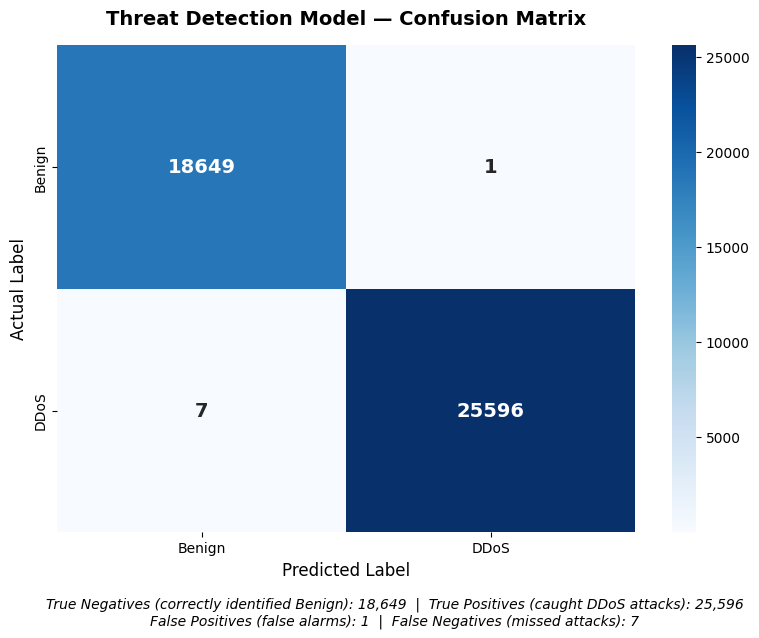

Confusion matrix saved

Missed attacks (False Negatives): 7
False alarms (False Positives):   1


In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title('Threat Detection Model — Confusion Matrix',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# Add explanation text below the chart
tn, fp, fn, tp = cm.ravel()
plt.figtext(0.5, -0.05,
    f'True Negatives (correctly identified Benign): {tn:,}  |  '
    f'True Positives (caught DDoS attacks): {tp:,}\n'
    f'False Positives (false alarms): {fp:,}  |  '
    f'False Negatives (missed attacks): {fn:,}',
    ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('../outputs/03-confusion-matrix.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved")
print(f"\nMissed attacks (False Negatives): {fn:,}")
print(f"False alarms (False Positives):   {fp:,}")

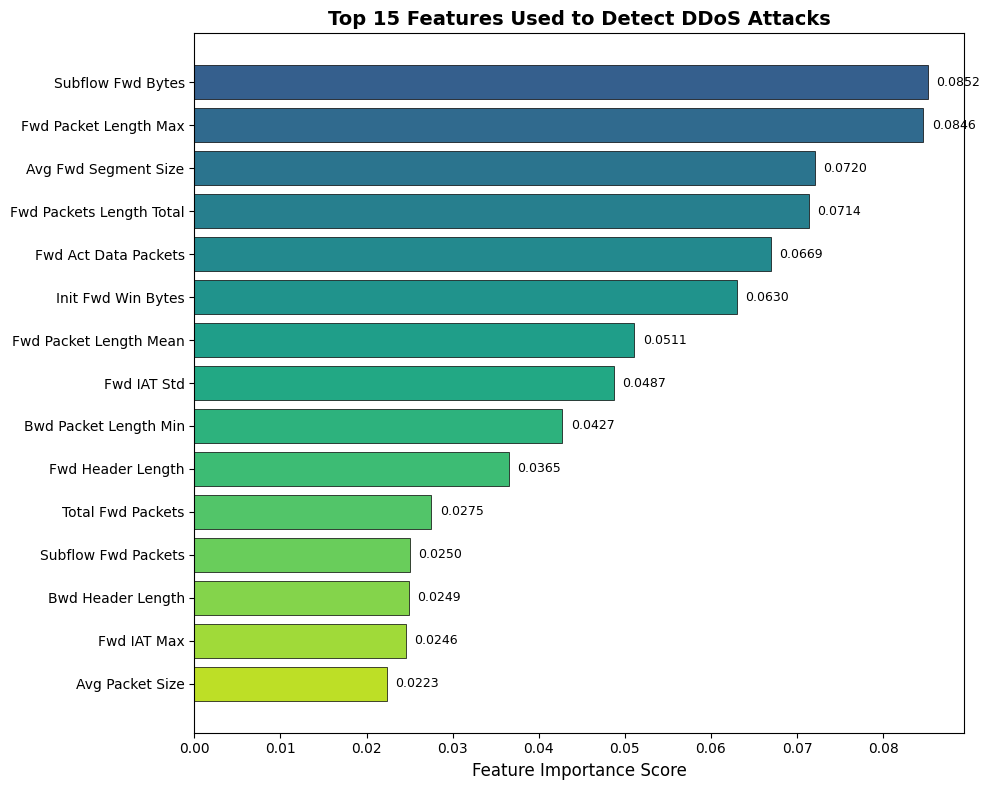

Feature importance chart saved

Top 5 most important features:
  Subflow Fwd Bytes: 0.0852
  Fwd Packet Length Max: 0.0846
  Avg Fwd Segment Size: 0.0720
  Fwd Packets Length Total: 0.0714
  Fwd Act Data Packets: 0.0669


In [11]:
# Feature importance tells you WHICH network behaviors
# the model uses most to detect DDoS attacks
# This is critical for explaining your work in interviews

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
bars = ax.barh(importance_df['Feature'],
               importance_df['Importance'],
               color=colors, edgecolor='black', linewidth=0.5)

# Add value labels on each bar
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Top 15 Features Used to Detect DDoS Attacks',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/03-feature-importance.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("Feature importance chart saved")
print(f"\nTop 5 most important features:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

In [12]:
# Simulate what happens when a real network flow comes in
# Pick one sample from the test set and predict it manually

sample_index = 42  # Pick any row
sample_features = X_test[sample_index].reshape(1, -1)
actual_label = le.inverse_transform([y_test[sample_index]])[0]

# Make prediction
prediction = model.predict(sample_features)[0]
probabilities = model.predict_proba(sample_features)[0]
predicted_label = le.inverse_transform([prediction])[0]
confidence = max(probabilities) * 100

print("=" * 50)
print("SINGLE FLOW PREDICTION TEST")
print("=" * 50)
print(f"Actual traffic type:    {actual_label}")
print(f"Model prediction:       {predicted_label}")
print(f"Confidence:             {confidence:.2f}%")
print(f"Correct prediction:     {'YES ✓' if actual_label == predicted_label else 'NO ✗'}")
print()
print(f"Probability breakdown:")
for label, prob in zip(le.classes_, probabilities):
    bar = '█' * int(prob * 30)
    print(f"  {label:8s}: {prob*100:6.2f}% {bar}")

SINGLE FLOW PREDICTION TEST
Actual traffic type:    DDoS
Model prediction:       DDoS
Confidence:             100.00%
Correct prediction:     YES ✓

Probability breakdown:
  Benign  :   0.00% 
  DDoS    : 100.00% ██████████████████████████████


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [13]:
# Save the model so Day 4 can load it for the API
with open('../models/threat_detection_model.pkl', 'wb') as f:
    pickle.dump(model, f)

model_size = os.path.getsize('../models/threat_detection_model.pkl')
print(f"Model saved to models/threat_detection_model.pkl")
print(f"Model size: {model_size / (1024*1024):.1f} MB")

# Save results summary
results = {
    'model_type': 'RandomForestClassifier',
    'n_estimators': 100,
    'accuracy': round(float(accuracy), 4),
    'f1_score': round(float(f1), 4),
    'precision': round(float(precision), 4),
    'recall': round(float(recall), 4),
    'false_negatives': int(fn),
    'false_positives': int(fp),
    'training_samples': len(X_train),
    'testing_samples': len(X_test),
    'top_feature': importance_df.iloc[0]['Feature']
}

with open('../outputs/03-model-results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nModel results saved to outputs/03-model-results.json")
print("\nSummary:")
for key, value in results.items():
    print(f"  {key}: {value}")

Model saved to models/threat_detection_model.pkl
Model size: 1.5 MB

Model results saved to outputs/03-model-results.json

Summary:
  model_type: RandomForestClassifier
  n_estimators: 100
  accuracy: 0.9998
  f1_score: 0.9998
  precision: 1.0
  recall: 0.9997
  false_negatives: 7
  false_positives: 1
  training_samples: 177011
  testing_samples: 44253
  top_feature: Subflow Fwd Bytes


In [14]:
# Check if the model file is under 100MB (GitHub's limit)
model_size_mb = os.path.getsize('../models/threat_detection_model.pkl') / (1024*1024)
print(f"Model file size: {model_size_mb:.1f} MB")

if model_size_mb > 90:
    print("Model is too large for GitHub — will add to .gitignore")
    print("Add this line to your .gitignore file: models/threat_detection_model.pkl")
else:
    print("Model is under 100MB — safe to push to GitHub")

Model file size: 1.5 MB
Model is under 100MB — safe to push to GitHub
